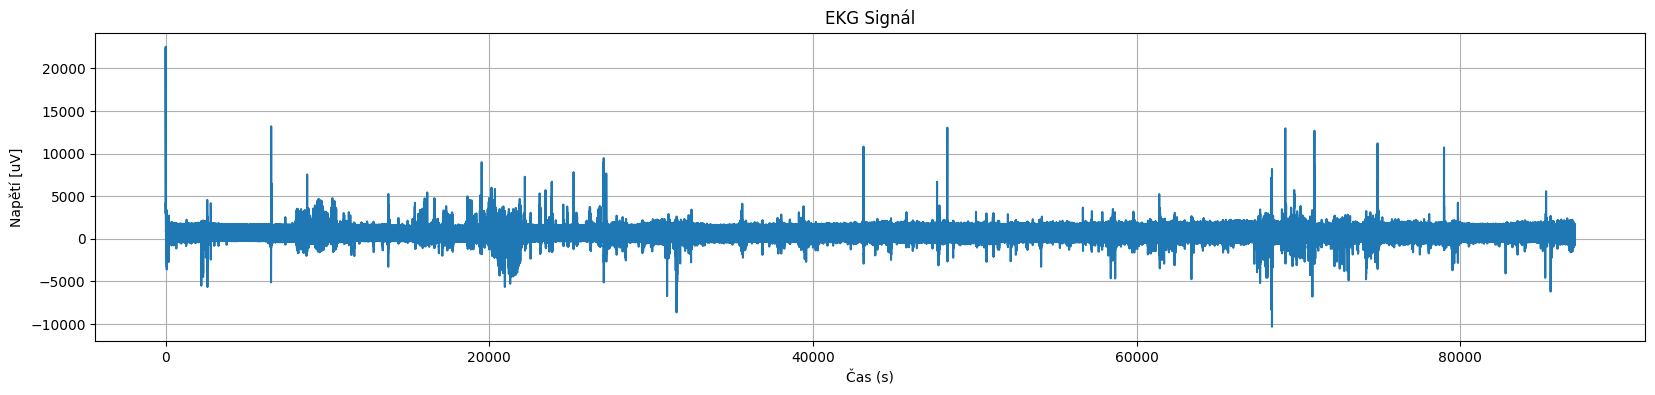

C:\Users\imang\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


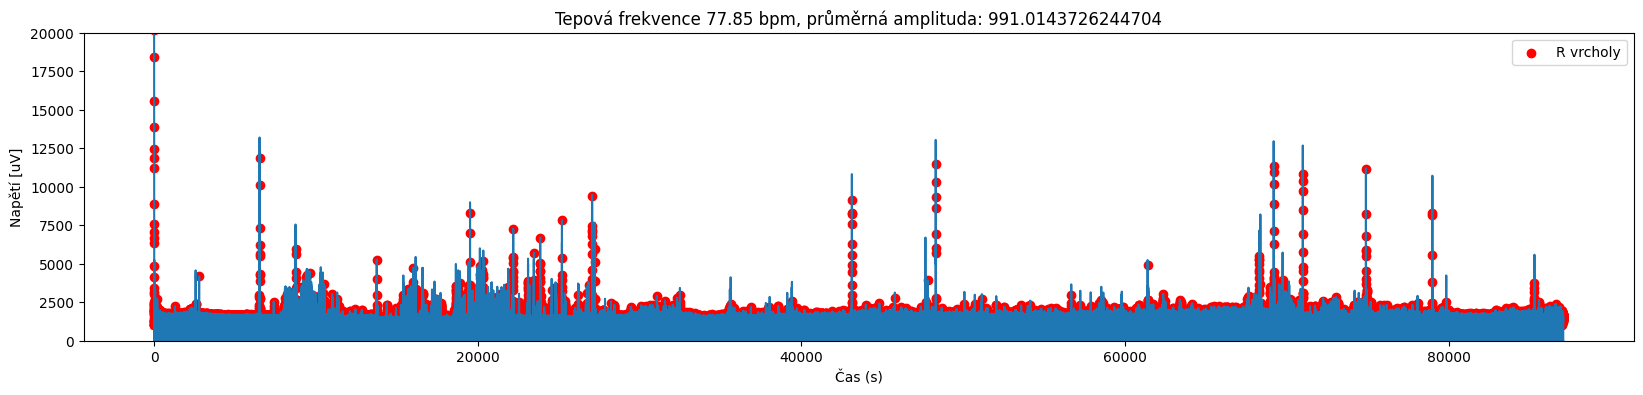

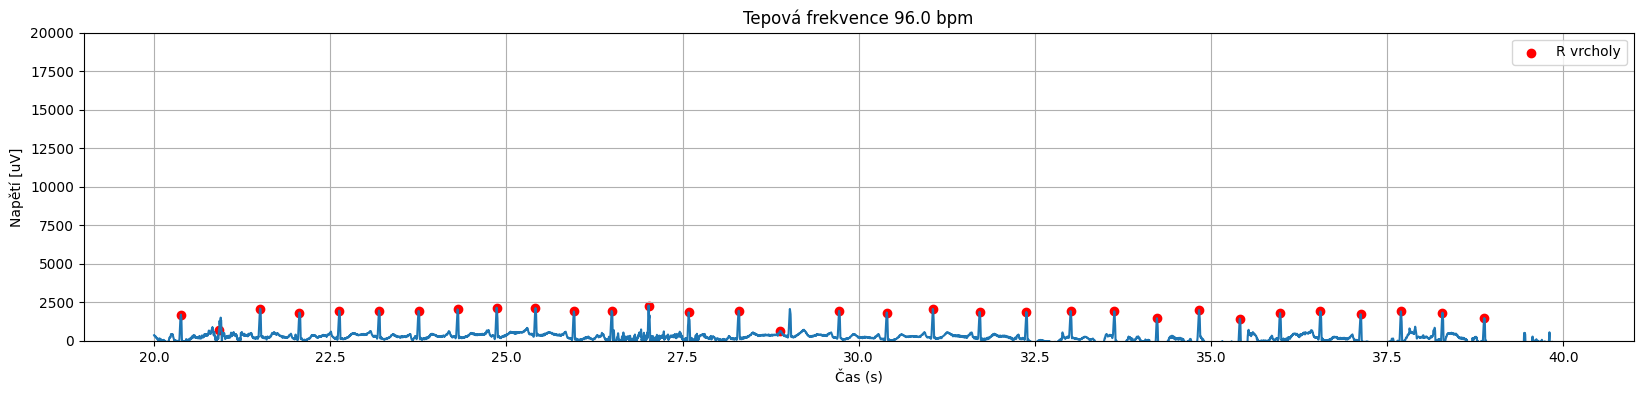

In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

# Funkce pro načtení souboru
def load_ecg_file(file_path):
    return wfdb.rdrecord(file_path)

# Funkce pro vykreslení EKG signálu
def plot_ecg_signal(time_axis, ecg_signal, title, xlabel, ylabel, ylim=None):
    plt.figure(figsize=(20, 4))
    plt.plot(time_axis, ecg_signal)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if ylim:
        plt.ylim(ylim)
    plt.grid()
    plt.show()

# Funkce pro výpočet průměrné frekvence
def calculate_average_amplitude(amplitudes, lower_threshold):
    valid_values = [value for value in amplitudes if value > lower_threshold]
    return sum(valid_values) / len(valid_values) if valid_values else 0

# Funkce pro detekci R vrcholů
def detect_r_peaks(ecg_signal, min_peak_height, min_distance):
    r_peaks = []
    for i in range(1, len(ecg_signal)-1):
        if ecg_signal[i] > min_peak_height:
            if (ecg_signal[i] > ecg_signal[i-1] and ecg_signal[i] > ecg_signal[i+1]) or \
               (ecg_signal[i] > ecg_signal[i-1] and ecg_signal[i] > ecg_signal[i+2]):
                if len(r_peaks) == 0 or (i - r_peaks[-1] >= min_distance):
                    r_peaks.append(i)
    return r_peaks

# Funkce pro výpočet tepové frekvence
def calculate_heart_rate(r_peaks, start_time, end_time):
    return (len(r_peaks) * 60) / (end_time - start_time)

# Načítání dat z MIT-BIH databáze
file_path = r"C:\Users\ondra\OneDrive\Plocha\brno-university-of-technology-ecg-quality-database-but-qdb-1.0.0\103002\103002_ECG"
ecg_data = load_ecg_file(file_path)
ecg_signal = ecg_data.p_signal
sampling_rate = ecg_data.fs
signal_duration = len(ecg_signal) / sampling_rate
time_axis = np.linspace(0, signal_duration, len(ecg_signal))

# Vykreslení celkového EKG signálu
plot_ecg_signal(time_axis, ecg_signal, "EKG Signál", "Čas (s)", "Napětí [uV]")

# Výpočet průměrné amplitudy pro R vrcholy
amplitudes = ecg_signal[:, 0]
lower_threshold = 300
average_amplitude = calculate_average_amplitude(amplitudes, lower_threshold)

# Detekce R vrcholů v signálu
min_peak_height = average_amplitude
min_distance = int(sampling_rate * 0.5)
r_peaks = detect_r_peaks(ecg_signal, min_peak_height, min_distance)

# Výpočet tepové frekvence
heart_rate = calculate_heart_rate(r_peaks, start_time=0, end_time=signal_duration)

# Vykreslení R vrcholů na EKG signálu
plt.figure(figsize=(20, 4))
plt.plot(time_axis, ecg_signal)
plt.title( "EKG Signál (20-40 sekund)")
plt.xlabel("Čas (s)")
plt.ylabel("Napětí [uV]")
plt.ylim([0,20000])
plt.scatter([time_axis[i] for i in r_peaks], [ecg_signal[i] for i in r_peaks], color='red', label="R vrcholy")
plt.title(f"Tepová frekvence {round(heart_rate, 2)} bpm, průměrná amplituda: {average_amplitude}")
plt.legend()
plt.show()

# Funkce pro vykreslení signálu na konkrétní časové ose
def plot_ecg_segment(time_axis, ecg_signal, r_peaks, average_amplitude, start_time, end_time):
    start_idx = int(sampling_rate * start_time)
    end_idx = int(sampling_rate * end_time)
    ecg_segment = ecg_signal[start_idx:end_idx]
    time_segment = np.linspace(start_time, end_time, len(ecg_segment))

    min_peak_height = calculate_average_amplitude(ecg_segment, lower_threshold)
    r_peaks_segment = detect_r_peaks(ecg_segment, min_peak_height, min_distance)
    heart_rate_segment = calculate_heart_rate(r_peaks_segment, start_time, end_time)


    plt.figure(figsize=(20, 4))
    plt.plot(time_segment, ecg_segment)
    plt.title( "EKG Signál (20-40 sekund)")
    plt.xlabel("Čas (s)")
    plt.ylabel("Napětí [uV]")
    plt.ylim([0,20000])
    plt.scatter([time_segment[i] for i in r_peaks_segment], [ecg_segment[i] for i in r_peaks_segment], color='red', label="R vrcholy")
    plt.title(f"Tepová frekvence {round(heart_rate_segment, 2)} bpm")
    plt.legend()
    plt.grid()
    plt.show()

# Vykreslení segmentu signálu mezi 20. a 40. sekundou
plot_ecg_segment(time_axis, ecg_signal, r_peaks, average_amplitude, start_time=20, end_time=40)


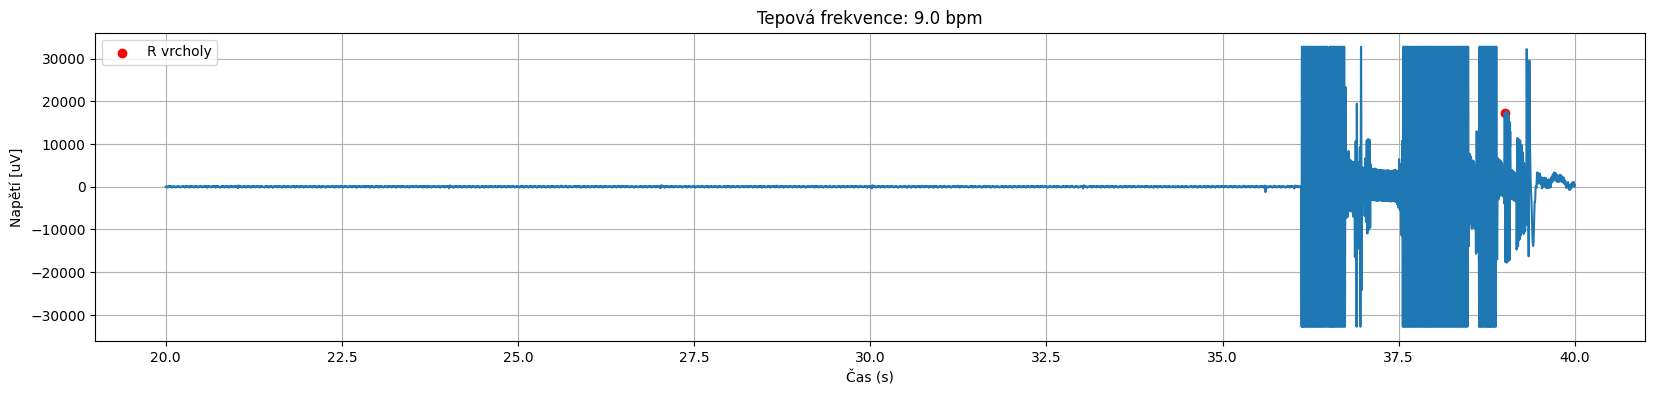

In [9]:
#Načtení dalšího EKG signálu
new_ecg_data = load_ecg_file(r"C:\Users\ondra\OneDrive\Plocha\brno-university-of-technology-ecg-quality-database-but-qdb-1.0.0\105001\105001_ECG")

# Extrakce signálu a vzorkovací frekvence
new_ecg_signal = new_ecg_data.p_signal[:, 0]
sampling_rate = new_ecg_data.fs

# Definování časového intervalu
interval_start = 20
interval_end = 40
start_idx = int(sampling_rate * interval_start)
end_idx = int(sampling_rate * interval_end)

# Výběr segmentu signálu
segmented_signal = new_ecg_signal[start_idx:end_idx]
time_segment = np.linspace(interval_start, interval_end, len(segmented_signal))

# Výpočet průměrné amplitudy
threshold_limit = 300
average_amplitude = calculate_average_amplitude(segmented_signal, threshold_limit)

# Parametry pro detekci R-vrcholů
peak_threshold = average_amplitude
min_peak_gap = int(sampling_rate * 0.5)

# Detekce R-vrcholů v segmentu
r_peak_positions = detect_r_peaks(segmented_signal, peak_threshold, min_peak_gap)

# Výpočet tepové frekvence
heart_rate_segment = calculate_heart_rate(r_peak_positions, interval_start, interval_end)

# Vykreslení segmentu signálu s detekovanými R-vrcholy
plt.figure(figsize=(20, 4))
plt.plot(time_segment, segmented_signal)
plt.title("EKG Segment 20-40s",)
plt.xlabel("Čas (s)")
plt.ylabel("Napětí [uV]")
plt.scatter([time_segment[i] for i in r_peak_positions], [segmented_signal[i] for i in r_peak_positions], color='red', label="R vrcholy")
plt.title(f"Tepová frekvence: {round(heart_rate_segment, 2)} bpm")
plt.legend()
plt.grid()
plt.show()

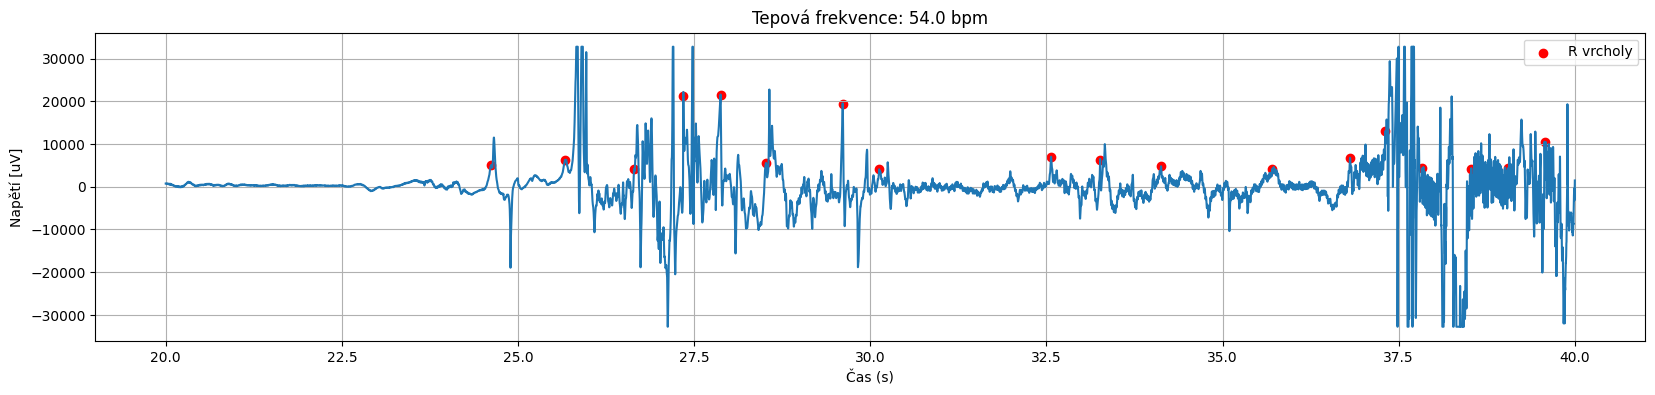

In [ ]:
#Načtení dalšího EKG signálu
new_ecg_data = load_ecg_file(r"C:\Users\ondra\OneDrive\Plocha\brno-university-of-technology-ecg-quality-database-but-qdb-1.0.0\122001\122001_ECG")

# Extrakce signálu a vzorkovací frekvence
new_ecg_signal = new_ecg_data.p_signal[:, 0]
sampling_rate = new_ecg_data.fs

# Definování časového intervalu
interval_start = 20
interval_end = 40
start_idx = int(sampling_rate * interval_start)
end_idx = int(sampling_rate * interval_end)

# Výběr segmentu signálu
segmented_signal = new_ecg_signal[start_idx:end_idx]
time_segment = np.linspace(interval_start, interval_end, len(segmented_signal))

# Výpočet průměrné amplitudy
threshold_limit = 300
average_amplitude = calculate_average_amplitude(segmented_signal, threshold_limit)

# Parametry pro detekci R-vrcholů
peak_threshold = average_amplitude
min_peak_gap = int(sampling_rate * 0.5)

# Detekce R-vrcholů v segmentu
r_peak_positions = detect_r_peaks(segmented_signal, peak_threshold, min_peak_gap)

# Výpočet tepové frekvence
heart_rate_segment = calculate_heart_rate(r_peak_positions, interval_start, interval_end)

# Vykreslení segmentu signálu s detekovanými R-vrcholy
plt.figure(figsize=(20, 4))
plt.plot(time_segment, segmented_signal)
plt.title("EKG Segment 20-40s",)
plt.xlabel("Čas (s)")
plt.ylabel("Napětí [uV]")
plt.scatter([time_segment[i] for i in r_peak_positions], [segmented_signal[i] for i in r_peak_positions], color='red', label="R vrcholy")
plt.title(f"Tepová frekvence: {round(heart_rate_segment, 2)} bpm")
plt.legend()
plt.grid()
plt.show()